In [30]:
import pandas as pd

In [31]:
df = pd.read_csv("../data/tweets.csv")
df.sample(10)

,id,label,tweet
27126,27127,0,life is what you make it. letâs make it ! #...
11061,11062,0,if i go to sleep... tomorrow will arrive faste...
27494,27495,0,@user i'm weak ð­
10832,10833,0,over privileged black child who's been brainwa...
2353,2354,0,- sirf ashiq mizaj log follow karen #iqbal #ga...
21294,21295,1,@user silence betrays the innocent. #activism ...
11655,11656,0,when you just want to be hand fed! #puppy #dog...
19457,19458,1,#cnn calls #michigan middle school 'build the ...
30923,30924,0,resiliency for life: why are you ?
29303,29304,0,rumbo al work


## Preprocessing text
- we can see that `@user` is being repeated in the text - we can remove it to enhance the training.
- we can replace all the uppercase letters with lowercase ones; this might have some issues, for instance `FATHER` might imply a different sentiment than `father`, but we can also agree upon the fact that all uppercase could be examples of memes (which indicate a positive feeling maybe) or someone shouting angrily in a tweet. We are doing this to lower the computation in an exchange for a negligible accuracy loss.
- we can also remove punctuation (e.g. `!`, `?`, `:`, and `.`).
- we can also get rif of stop words (e.g. `the`, `of`, and `a`).
- stemming could be performed to reduce the volume of calculations (e.g. motiv instead of motivation, motivate, and motivated).
- lemmatization could be applied on the text to reduce the complexity (e.g. good for well, better, and best).

In [32]:
df['new_tweet'] = df['tweet'].str.replace('@user', '')
df.head(5)

,id,label,tweet,new_tweet
0,1,0,@user when a father is dysfunctional and is s...,when a father is dysfunctional and is so sel...
1,2,0,@user @user thanks for #lyft credit i can't us...,thanks for #lyft credit i can't use cause th...
2,3,0,bihday your majesty,bihday your majesty
3,4,0,#model i love u take with u all the time in ...,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation,factsguide: society now #motivation


In [33]:
df["new_tweet"] = df["new_tweet"].str.replace("[^a-zA-Z#]", "")
df["new_tweet"] = df["new_tweet"].str.replace("#", "")

In [34]:
from collections import Counter
all_words = []
for line in list(df["new_tweet"]):
    words = line.split()
    for word in words:
        all_words.append(word.lower())
        
a = Counter(all_words).most_common(10)
print(a)

[('the', 10087), ('to', 9780), ('a', 6387), ('i', 5676), ('you', 4980), ('and', 4842), ('in', 4579), ('for', 4438), ('of', 4155), ('is', 4108)]


In [35]:
# tokenizing
df["new_tweet"] = df["new_tweet"].apply(lambda x: x.split())
df.head(5)

,id,label,tweet,new_tweet
0,1,0,@user when a father is dysfunctional and is s...,"[when, a, father, is, dysfunctional, and, is, ..."
1,2,0,@user @user thanks for #lyft credit i can't us...,"[thanks, for, lyft, credit, i, can't, use, cau..."
2,3,0,bihday your majesty,"[bihday, your, majesty]"
3,4,0,#model i love u take with u all the time in ...,"[model, i, love, u, take, with, u, all, the, t..."
4,5,0,factsguide: society now #motivation,"[factsguide:, society, now, motivation]"


In [36]:
# stemming
# we have 2 main stemming strategies: 1- snowball 2- porter
# 1- snowball is more aggressive, and it is effective in reducing the repeated words but it is prone to over-stemming
# 2- porter is less aggressive
from nltk.stem.snowball import SnowballStemmer
stemmer = SnowballStemmer("english")

df["new_tweet"] = df["new_tweet"].apply(lambda x: [stemmer.stem(i) for i in x])
df.head(5)

,id,label,tweet,new_tweet
0,1,0,@user when a father is dysfunctional and is s...,"[when, a, father, is, dysfunct, and, is, so, s..."
1,2,0,@user @user thanks for #lyft credit i can't us...,"[thank, for, lyft, credit, i, can't, use, caus..."
2,3,0,bihday your majesty,"[bihday, your, majesti]"
3,4,0,#model i love u take with u all the time in ...,"[model, i, love, u, take, with, u, all, the, t..."
4,5,0,factsguide: society now #motivation,"[factsguide:, societi, now, motiv]"


In [37]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\atareversei\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [38]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
stopwords = nltk.corpus.stopwords.words('english')
newStopWords = ['u', 'go', 'got', 'via', 'or', 'ur', 'us', 'in', 'let', 'the', 'to', 'is', 'amp', 'make', 'one', 'day']
stopwords.extend(newStopWords)


In [39]:
import string

def process(text):
    no_punc = set(char for char in list(text) if char not in string.punctuation)
    no_punc = " ".join(no_punc)
    return [word for word in no_punc.lower().split() if word.lower() not in stopwords]


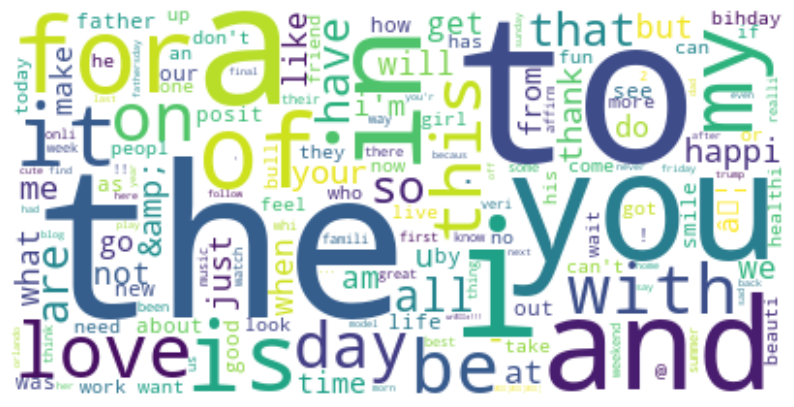

In [40]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

words = []
for line in df["new_tweet"]:
    words.extend(line)
    
word_freq = Counter(words)
word_cloud = WordCloud(
    background_color="white",
    max_words=2000,
    stopwords=stopwords,
).generate_from_frequencies(word_freq)
plt.figure(figsize=(10, 9))
plt.imshow(word_cloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [41]:
def string(text):
    to_return = ""
    for i in list(text):
        to_return += str(i) + " "
    
    to_return = to_return[:-1]
    return to_return

df["new_tweet"] = df["new_tweet"].apply(string)
df.head(5)

,id,label,tweet,new_tweet
0,1,0,@user when a father is dysfunctional and is s...,when a father is dysfunct and is so selfish he...
1,2,0,@user @user thanks for #lyft credit i can't us...,thank for lyft credit i can't use caus they do...
2,3,0,bihday your majesty,bihday your majesti
3,4,0,#model i love u take with u all the time in ...,model i love u take with u all the time in urð...
4,5,0,factsguide: society now #motivation,factsguide: societi now motiv


In [42]:
df.drop(["id", "tweet"], axis=1, inplace=True)
df.head()

,label,new_tweet
0,0,when a father is dysfunct and is so selfish he...
1,0,thank for lyft credit i can't use caus they do...
2,0,bihday your majesti
3,0,model i love u take with u all the time in urð...
4,0,factsguide: societi now motiv


In [43]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(df["new_tweet"], df["label"], random_state=42)

In [46]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
count_vect = CountVectorizer(stop_words='english')
transformer = TfidfTransformer(norm='l2', sublinear_tf=True)

In [47]:
x_train_count = count_vect.fit_transform(x_train)
x_train_tfidf = transformer.fit_transform(x_train_count)

In [48]:
x_test_count = count_vect.transform(x_test)
x_test_tfidf = transformer.transform(x_test_count)

In [49]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(x_train_tfidf, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [50]:
predictions = model.predict(x_test_tfidf)

In [51]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, predictions) * 100

95.98298085346015

In [52]:
from sklearn.metrics import f1_score
f1_score(y_test, predictions) * 100

64.05375139977603

## f1 score
f1 score is lower because the data was imbalanced (much of the data was label=0). To overcome this challenge we can, either use undersampling
or oversampling.

In [53]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
x_train_tfidf_resampled, y_train_tfidf_resampled = sm.fit_resample(x_train_tfidf, y_train)
y_train_tfidf_resampled.value_counts()

label
0    22288
1    22288
Name: count, dtype: int64